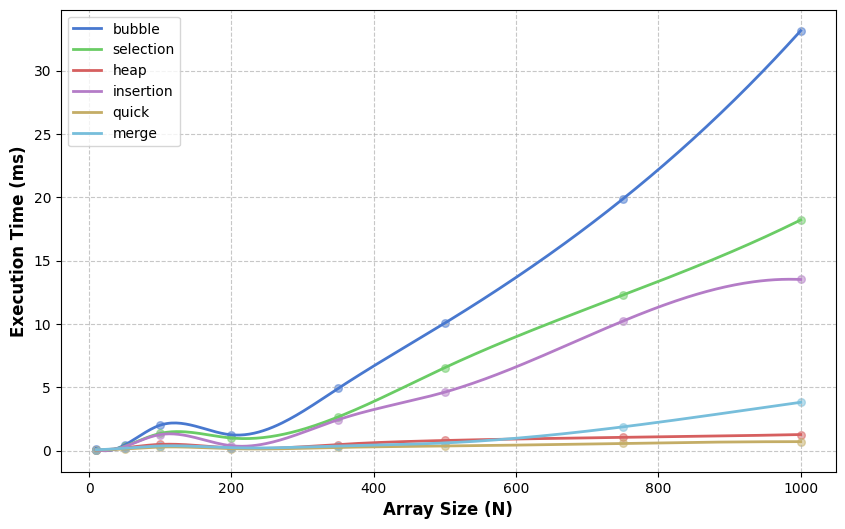

In [22]:
import numpy as np
from scipy.interpolate import make_interp_spline
import requests
import pandas as pd
import matplotlib.pyplot as plt

def collect_data():
    results = []
    sizes =[10,50,100,200,350,500,750,1000]
    algos=["bubble","selection","heap", "insertion","quick","merge"]
    for size in sizes:
        params = {'size':size,'type':'Random'}
        response = requests.get(f'http://localhost:8080/api/Data/getArr', params=params)


        for algo in algos:
            params = {'algo':algo, 'size':size,'type':'Random'}
            try:
                response = requests.get(f'http://localhost:8080/api/Data', params=params)
                if response.status_code == 200:
                    results.append(response.json())
            except Exception as e:
                print(f"Error: {e}")
    return pd.DataFrame(results)

df = collect_data()

plt.figure(figsize=(10, 6))

for algo in df['algo'].unique():
    subset = df[df['algo'] == algo].sort_values('size')
    x = subset['size'].values
    y = subset['time'].values

    if len(x) > 3:
        x_smooth = np.linspace(x.min(), x.max(), 300)
        spl = make_interp_spline(x, y, k=3)
        y_smooth = spl(x_smooth)
        plt.plot(x_smooth, y_smooth, label=algo, linewidth=2)
        plt.scatter(x, y, s=30, alpha=0.5)
    else:
        plt.plot(x, y, label=algo, marker='o')

plt.xlabel("Array Size (N)", fontsize=12, fontweight='bold')
plt.ylabel("Execution Time (ms)", fontsize=12, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.style.use('seaborn-v0_8-muted')
plt.tight_layout()
plt.savefig('sorting_benchmark.png', dpi=300)
plt.show()